# Notebook to test the retrieval before launching it

In [1]:
from pathlib import Path

from sys import path  # add directory where starships is located
path.append('/home/mathisb/Github/starships')

import numpy as np
import matplotlib.pyplot as plt

import re
from importlib import reload

from starships import retrieval
from starships.plotting_fcts import get_plot_labels
import starships.retrieval_utils as retrieval_utils
import starships.planet_obs as pl_obs

from starships import petitradtrans_utils

petitradtrans_utils.log.setLevel('INFO')
pl_obs.log.setLevel("WARNING")

In [2]:
petitradtrans_utils.log.setLevel('DEBUG')
retrieval_utils.log.setLevel('DEBUG')
retrieval.log.setLevel('DEBUG')

## Prepare the retrieval

In [3]:
yaml_path_in = Path.home() / Path('/home/mathisb/Github/HRS_analysis/retrievals/')
yaml_file_in = yaml_path_in / Path('trappist1f_grid_CH4.yaml')

In [4]:
kwargs = dict(
#     init_mode='continue',
#     walker_file_in='walker_steps_emission_JR_wfc3_spitzer_modif_disso_32044231.h5'
    # p_cloud = 2
)

In [5]:
retrieval.setup_retrieval(input_parameters=yaml_file_in, **kwargs)

INFO:starships.retrieval:spectrophotometric_data is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:photometric_data is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:linelist_names is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:reg_fixed_params is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:special_init is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:No walker file out name given. Setting it to walker_steps_N2_CH4_bothlinear.h5
INFO:starships.retrieval:pl_name = TRAPPIST-1 f
INFO:starships.retrieval:instrum = ['nirps_he', 'nirps_he', 'nirps_he']
INFO:starships.retrieval:high_res_path = /home/mathisb/scratch/HRS_reductions/NIRPS_Apr2026/TRAPPIST-1f
INFO:starships.retrieval:high_res_file_stem_list = ['2023-08-28/v001/retrieval_input_0-pc_mask_wings97', '2024-11-02/v001/retrieval_input_0-pc_mask_wings97', '2025-08-06/v001/retrieval_input_0-pc_mask_

{'pl_name': 'TRAPPIST-1 f',
 'instrum': ['nirps_he', 'nirps_he', 'nirps_he'],
 'high_res_path': PosixPath('/home/mathisb/scratch/HRS_reductions/NIRPS_Apr2026/TRAPPIST-1f'),
 'high_res_file_stem_list': ['2023-08-28/v001/retrieval_input_0-pc_mask_wings97',
  '2024-11-02/v001/retrieval_input_0-pc_mask_wings97',
  '2025-08-06/v001/retrieval_input_0-pc_mask_wings97'],
 'mid_tr_list': [2460184.827486578, 2460617.5481359637, 2460893.795434583],
 'orders': None,
 'pl_params': {'M_star': <Quantity 0.0898 solMass>,
  'R_star': <Quantity 0.1192 solRad>,
  'Teff': <Quantity 2520. K>,
  'M_pl': <Quantity 1.039 earthMass>,
  'R_pl': <Quantity 1.045 earthRad>,
  'Tp': <Quantity 217.7 K>,
  'ap': <Quantity 0.03849 AU>,
  'period': <Quantity 795531.456 s>,
  'excent': 0.0,
  'w': <Quantity 4.712389 rad>,
  'incl': <Quantity 1.56625847 rad>,
  'RV_sys': <Quantity -52.003101 km / s>,
  'trandur': <Quantity 3772.8 s>},
 'star_spectrum': None,
 'line_opacities': ['CH4'],
 'continuum_opacities': ['N2-N2'],


In [6]:
n_steps, pos, wlkr_file_out, yaml_file, good_to_go = retrieval.prepare_run(yaml_file=yaml_file_in, **kwargs)

INFO:starships.retrieval:spectrophotometric_data is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:photometric_data is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:linelist_names is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:reg_fixed_params is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:special_init is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:No walker file out name given. Setting it to walker_steps_N2_CH4_bothlinear.h5
INFO:starships.retrieval:pl_name = TRAPPIST-1 f
INFO:starships.retrieval:instrum = ['nirps_he', 'nirps_he', 'nirps_he']
INFO:starships.retrieval:high_res_path = /home/mathisb/scratch/HRS_reductions/NIRPS_Apr2026/TRAPPIST-1f
INFO:starships.retrieval:high_res_file_stem_list = ['2023-08-28/v001/retrieval_input_0-pc_mask_wings97', '2024-11-02/v001/retrieval_input_0-pc_mask_wings97', '2025-08-06/v001/retrieval_input_0-pc_mask_

  Read line opacities of CH4_Hargreaves_main_iso...
 Done.

  Read CIA opacities for H2-H2...
  Read CIA opacities for H2-He...
  Read CIA opacities for N2-N2...


INFO:starships.petitradtrans_utils:Generating atmosphere with pressures from 100.0 to 1e-10
INFO:starships.petitradtrans_utils:You are not getting the individual contributions of the species
INFO:starships.retrieval:Saving values in `linelist_names`.
INFO:starships.retrieval:Star spectrum not initialized for mode = high. Starting initialization...
INFO:starships.retrieval:No stellar spectrum provided. A blackbody at Teff will be used.
DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
DEBUG:starships.petitradtrans_utils:Calculating abundances
DEBUG:starships.petitradtrans_utils:In gen_abundances: species_list = ['CH4_Hargreaves_main_iso', 'N2']
DEBUG:starships.petitradtrans_utils:In gen_abundances: VMRs = [0.6542520320887183, 0.08736009677059409]


Done.



DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
DEBUG:starships.petitradtrans_utils:Calculating abundances
DEBUG:starships.petitradtrans_utils:In gen_abundances: species_list = ['CH4_Hargreaves_main_iso', 'N2']
DEBUG:starships.petitradtrans_utils:In gen_abundances: VMRs = [0.6542520320887183, 0.08736009677059409]
DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
DEBUG:starships.petitradtrans_utils:Calculating abundances
DEBUG:starships.petitradtrans_utils:In gen_abundances: species_list = ['CH4_Hargreaves_main_iso', 'N2']
DEBUG:starships.petitradtrans_utils:In gen_abundances: VMRs = [0.6542520320887183, 0.08736009677059409]
DEBUG:starships.retrieval:Shape of individual logl for all exposures (all visits combined): (32, 75)
DEBUG:starships.retrieval:logL = 1079606.6764532377
INFO:starships.retrieval:log likelihood function is indeed working! Success!
INFO:starships.retrieval:File walker_steps_N2_CH4_bothlinear.h5 already exists.
INFO:starships.retrieval:T

In [7]:
good_to_go

True

In [8]:
# # Test VMRs
# from starships import petitradtrans_utils as prt_u

# def get_mol_profile(params, idx_region=0):

#     theta_dict = retrieval.unpack_theta(params)[idx_region]

#     # print(theta_dict)

#     species = retrieval.line_opacities + retrieval.continuum_opacities + retrieval.other_species

#     species.remove('N2-N2')
#     species.append('N2')

#     # print(species)
#     # Compute the abundances (and add species that need to be included if not fitted)
#     abundances, MMW, VMR = prt_u.gen_abundances(species, [theta_dict[key] for key in species],
#                                      theta_dict['pressures'], theta_dict['temperatures'],
#                                      verbose=False, vmrh2he=[0.85, 0.15],
#                                      dissociation=retrieval.dissociation, plot=False)

#     return VMR

In [9]:
# rng = np.random.default_rng()
# abundances_aa = rng.uniform(-12, 0, size=(15,2))

# for ab in abundances_aa:
#     vmr_H = get_mol_profile(ab)['H2'][0]
#     exp_nb = (1 - 10**ab[0] - 10**ab[1]) * 0.85

#     print(vmr_H - exp_nb)

## It is possible to re-run the prepare_run without reloading the yaml_file

In [9]:
n_steps, pos, wlkr_file_out, yaml_file, good_to_go = retrieval.prepare_run()

DEBUG:starships.retrieval:Hires files stem: /home/mathisb/scratch/HRS_reductions/NIRPS/TRAPPIST-1b/2024-07-05/v001/retrieval_input_1-pc_mask_wings97
INFO:starships.retrieval:Loading Hires files.
INFO:starships.retrieval:Number of steps: 2500
INFO:starships.retrieval:(Number of walker, Number of parameters) = (8, 2)
INFO:starships.retrieval:Checking if log likelihood function is working.
DEBUG:starships.retrieval:In `lnprob`, input array = [ -1.37626844 681.15739314]
DEBUG:starships.retrieval:Commpute Prior
DEBUG:starships.retrieval_utils:Prior for 'CO2' -> log_uniform([-12.0, -0.001]) = 0.0
DEBUG:starships.retrieval_utils:Prior for 'T_eq' -> uniform([50.0, 800.0]) = 0.0
DEBUG:starships.retrieval:Converting CO2 to 10**(CO2).
DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
DEBUG:starships.petitradtrans_utils:Calculating abundances
DEBUG:starships.petitradtrans_utils:In gen_abundances: species_list = ['CO2_main_iso']
DEBUG:starships.petitradtrans_utils:In gen_abundances: 

In [10]:
retrieval.unpack_theta(pos[0])

DEBUG:starships.retrieval:Converting CO2 to 10**(CO2).


[{'gravity': array([1080.96946305]),
  'P0': 1.0,
  'e-': -99,
  'H': -99,
  'H2': -99,
  'He': -99,
  'C/O': None,
  'Fe/H': None,
  'T_eq': 681.1573931430797,
  'cloud_fraction': None,
  'p_cloud': None,
  'scat_factor': None,
  'kp': 83.0803757155627,
  'rv': 0.0,
  'spec_scale': 1.0,
  'pressures': array([1.00000000e-07, 1.52641797e-07, 2.32995181e-07, 3.55648031e-07,
         5.42867544e-07, 8.28642773e-07, 1.26485522e-06, 1.93069773e-06,
         2.94705170e-06, 4.49843267e-06, 6.86648845e-06, 1.04811313e-05,
         1.59985872e-05, 2.44205309e-05, 3.72759372e-05, 5.68986603e-05,
         8.68511374e-05, 1.32571137e-04, 2.02358965e-04, 3.08884360e-04,
         4.71486636e-04, 7.19685673e-04, 1.09854114e-03, 1.67683294e-03,
         2.55954792e-03, 3.90693994e-03, 5.96362332e-03, 9.10298178e-03,
         1.38949549e-02, 2.12095089e-02, 3.23745754e-02, 4.94171336e-02,
         7.54312006e-02, 1.15139540e-01, 1.75751062e-01, 2.68269580e-01,
         4.09491506e-01, 6.25055193e-01, 

## To debug, you can test specific steps of the `lnprob` function

In [9]:
retrieval = reload(retrieval)

In [10]:
params = retrieval.walker_init[0]
print(params)

[0.0873601  0.65425203]


In [11]:
theta_regions = retrieval.unpack_theta(params)

In [12]:
wv, spec = retrieval.prepare_model_multi_reg(theta_regions, 'high', tr_i=0, Raf=retrieval.res_instru)

DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
DEBUG:starships.petitradtrans_utils:Calculating abundances
DEBUG:starships.petitradtrans_utils:In gen_abundances: species_list = ['CH4_Hargreaves_main_iso', 'N2']
DEBUG:starships.petitradtrans_utils:In gen_abundances: VMRs = [0.6542520320887183, 0.08736009677059409]


In [13]:
# Test the whole lnprob function
logl = retrieval.lnprob(params)

DEBUG:starships.retrieval:In `lnprob`, input array = [0.0873601  0.65425203]
DEBUG:starships.retrieval:Compute Prior
DEBUG:starships.retrieval_utils:Prior for 'N2' -> uniform([0.0, 1.0]) = 0.0
DEBUG:starships.retrieval_utils:Prior for 'CH4' -> uniform([0.0, 1.0]) = 0.0
DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
DEBUG:starships.petitradtrans_utils:Calculating abundances
DEBUG:starships.petitradtrans_utils:In gen_abundances: species_list = ['CH4_Hargreaves_main_iso', 'N2']
DEBUG:starships.petitradtrans_utils:In gen_abundances: VMRs = [0.6542520320887183, 0.08736009677059409]
DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
DEBUG:starships.petitradtrans_utils:Calculating abundances
DEBUG:starships.petitradtrans_utils:In gen_abundances: species_list = ['CH4_Hargreaves_main_iso', 'N2']
DEBUG:starships.petitradtrans_utils:In gen_abundances: VMRs = [0.6542520320887183, 0.08736009677059409]
DEBUG:starships.petitradtrans_utils:Chemical equilibrium = False
D

## Analyze result of grid retrieval

In [4]:
data = np.load('/home/mathisb/scratch/HRS_retrievals/grid_retrievals/N2_CH4.npz')

In [5]:
param1 = data['param1']
param2 = data['param2']
logl_result = data['logl']

# print(data['results'])

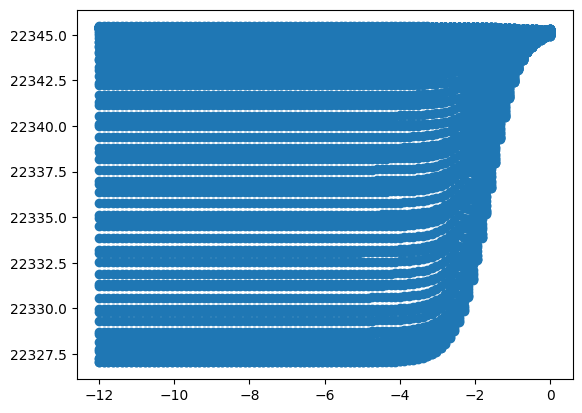

In [6]:
plt.scatter(param2, logl_result)
plt.show()

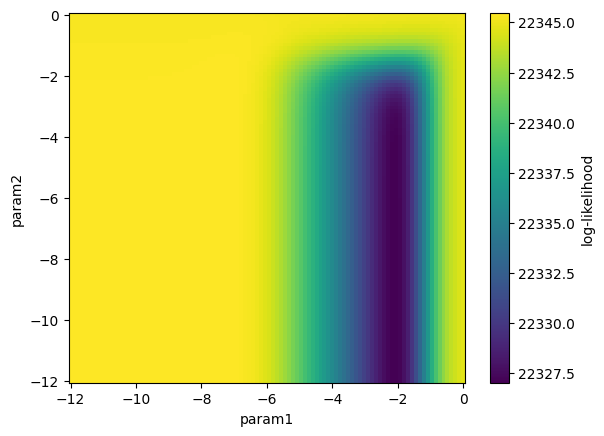

In [7]:
p1_unique = np.unique(param1)
p2_unique = np.unique(param2)

Z = logl_result.reshape(len(p2_unique), len(p1_unique))

plt.pcolormesh(
    p1_unique,
    p2_unique,
    Z,
    shading="auto"
)

plt.colorbar(label="log-likelihood")
plt.xlabel("param1")
plt.ylabel("param2")

plt.show()